## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

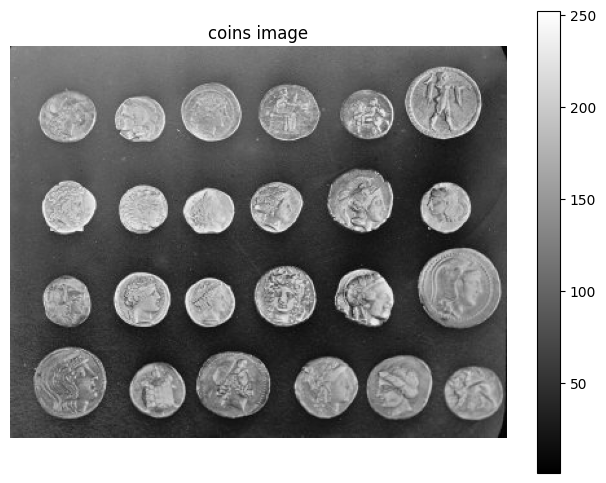

Image size (rows x cols): 303 x 384  ->  116352 pixels
Grayscale range         : min = 1, max = 252


In [32]:
# Load and visualize the 'coins' image from the skimage built-in datasets
import skimage as sk
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

# Load the image
I = data.coins()

# Visualize the image
fig = plt.figure(figsize=(8, 6))
plt.imshow(I, cmap=plt.cm.gray)
plt.title('coins image')
plt.colorbar(orientation='vertical')
plt.axis('off')
plt.show()

# Report the size of the image and the range of the grayscale levels
print('Image size (rows x cols): {} x {}  ->  {} pixels'.format(I.shape[0], I.shape[1], I.size))
print('Grayscale range         : min = {}, max = {}'.format(I.min(), I.max()))

## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

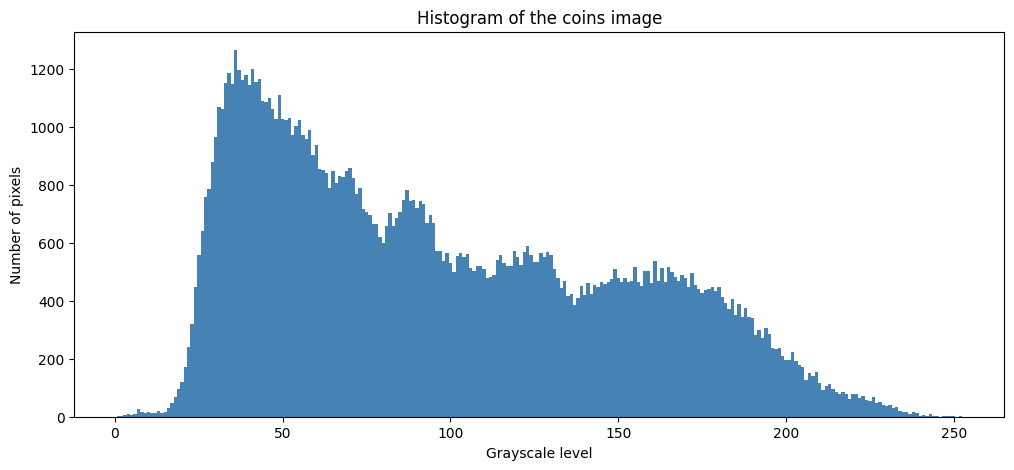

Dominant peak at grayscale level 36 with 1264 pixels


In [23]:
from skimage import exposure

counts, bin_centers = exposure.histogram(I, nbins=256)

fig = plt.figure(figsize=(12, 5))
plt.bar(bin_centers, counts, width=1.0, color='steelblue')
plt.xlabel('Grayscale level')
plt.ylabel('Number of pixels')
plt.title('Histogram of the coins image')
plt.show()

ind_max = np.argmax(counts)
print('Dominant peak at grayscale level {} with {} pixels'.format(bin_centers[ind_max], counts[ind_max]))

The plot is multimodal, so it reflects more than a simple background/coin split:

- Peak near 35 to 40: the dark, unlit table. Sharpest peak because the table tone is uniform, not because it covers the most area.
- Bump near 88: the same table where the lighting is brighter. Uneven illumination (top lighter than bottom) splits the background into a second hump, so this is still background, not coins.
- Spread from about 120 to 175: the coins, from worn or shadowed faces (which overlap the bright background) up to bright metallic ones.

Because the bright background and the coins overlap rather than being split by a clear valley, no single global threshold cleanly separates them.

## 3. Applied noise to the image and use the correct function to erase the noise.

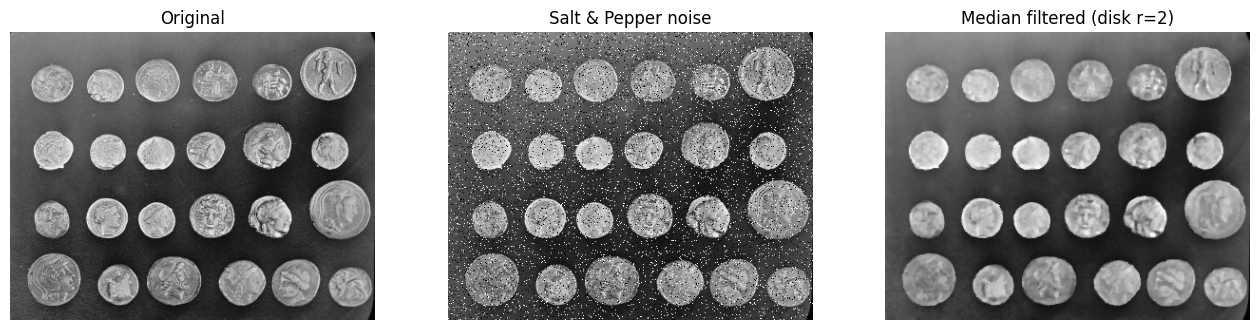

In [24]:
from skimage.util import random_noise, img_as_ubyte
from skimage.filters import median
from skimage.morphology import disk

# Add salt & pepper noise
noisy = img_as_ubyte(random_noise(I, mode='s&p', amount=0.08))

# The MEDIAN filter is the correct (statistical/non-linear) filter to erase salt &
# pepper noise: it replaces every pixel by the median of its neighbourhood, which
# discards the extreme (0/255) outliers while preserving the edges of the coins.
denoised = median(noisy, disk(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(I, cmap=plt.cm.gray);        ax[0].set_title('Original');                ax[0].axis('off')
ax[1].imshow(noisy, cmap=plt.cm.gray);    ax[1].set_title('Salt & Pepper noise');     ax[1].axis('off')
ax[2].imshow(denoised, cmap=plt.cm.gray); ax[2].set_title('Median filtered (disk r=2)'); ax[2].axis('off')
plt.show()

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

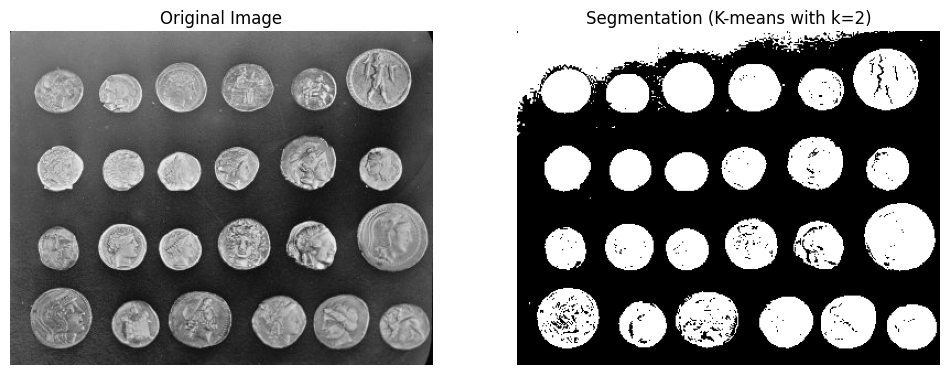

Cluster centers (grayscale level): [ 60.3 154.6]


In [25]:
from sklearn.cluster import KMeans

v_I = I.reshape(-1, 1)

n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0, n_init=10).fit(v_I)
v_kmeans = kmeans.predict(v_I)

fg = int(np.argmax(kmeans.cluster_centers_.ravel()))
seg = (v_kmeans == fg).reshape(I.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(I, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(seg, cmap=plt.cm.gray)
ax[1].set_title('Segmentation (K-means with k={})'.format(n_clus))
ax[1].axis('off')
plt.show()

print('Cluster centers (grayscale level): {}'.format(np.round(kmeans.cluster_centers_.ravel(), 1)))

The first coin (top-left) color is not separated from the background so K-means could not separate it well.

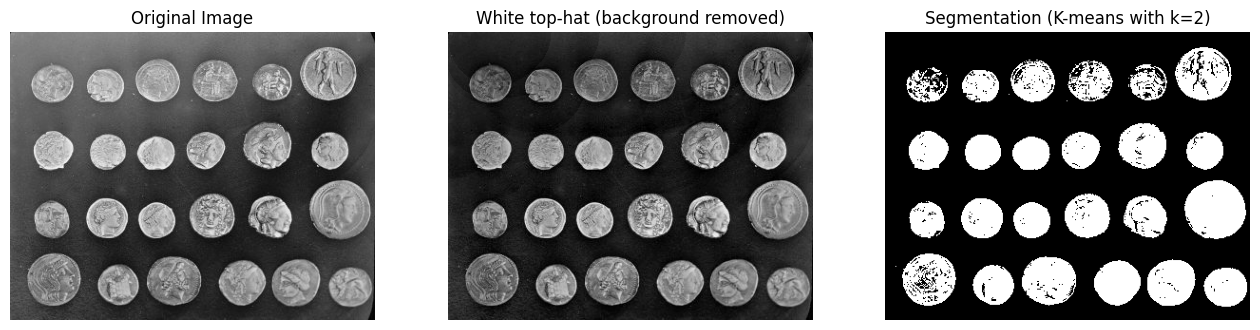

Cluster centers (grayscale level): [ 26.5 128.3]


In [34]:
from skimage.morphology import white_tophat, disk
# first remove the slowly-varying background with
# the white TOP-HAT transform

I_th = white_tophat(I, disk(50))

v_I = I_th.reshape(-1, 1)               # reshape as N x 1 (one intensity feature per pixel)

n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0, n_init=10).fit(v_I)
v_kmeans = kmeans.predict(v_I)

# Make sure the brighter cluster (the coins) is the foreground (label = 1):
fg = int(np.argmax(kmeans.cluster_centers_.ravel()))
seg = (v_kmeans == fg).reshape(I.shape)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(I, cmap=plt.cm.gray);    ax[0].set_title('Original Image');             ax[0].axis('off')
ax[1].imshow(I_th, cmap=plt.cm.gray); ax[1].set_title('White top-hat (background removed)'); ax[1].axis('off')
ax[2].imshow(seg, cmap=plt.cm.gray);  ax[2].set_title('Segmentation (K-means with k={})'.format(n_clus)); ax[2].axis('off')
plt.show()

print('Cluster centers (grayscale level): {}'.format(np.round(kmeans.cluster_centers_.ravel(), 1)))

## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

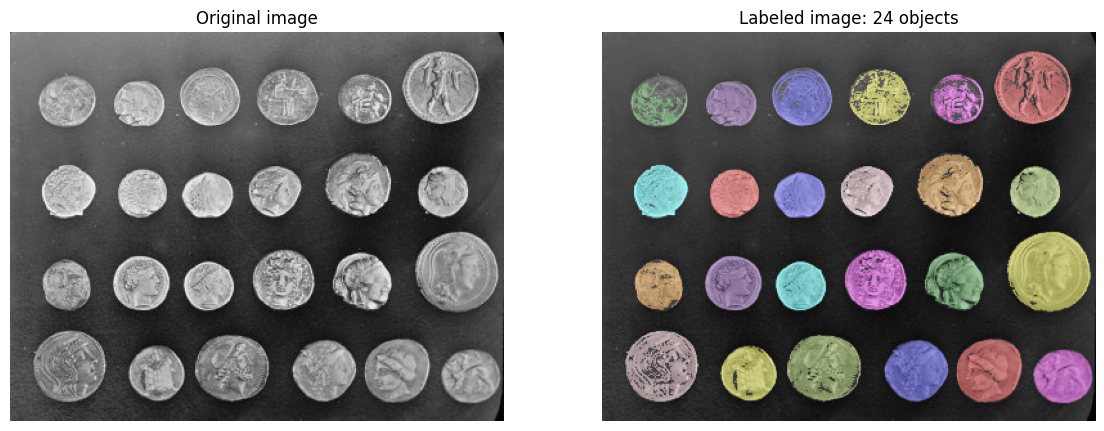

Number of coins found in the image: 24


In [35]:
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# Label the connected components (objects) of the K-means segmentation
label_image, _ = label(seg, return_num=True)

# Remove spurious small regions (area < 150 px) by re-labelling them as background,
for p in regionprops(label_image):
    if p.area < 150:
        label_image[label_image == p.label] = 0

# Re-label so that the coins get consecutive labels (1, 2, 3, ...)
label_image, ncoins = label(label_image > 0, return_num=True)
image_label_overlay = label2rgb(label_image, image=I, bg_label=0)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(I, cmap=plt.cm.gray);    ax[0].set_title('Original image');                 ax[0].axis('off')
ax[1].imshow(image_label_overlay);    ax[1].set_title('Labeled image: {} objects'.format(ncoins)); ax[1].axis('off')
plt.show()

print('Number of coins found in the image: {}'.format(ncoins))
# The coins are arranged in a 4 x 6 grid, so the expected number of coins is 24.

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  


AVERAGE area               = 1488.46 pixels
AVERAGE major axis length  = 46.52 pixels
AVERAGE orientation        = -14.20 degrees


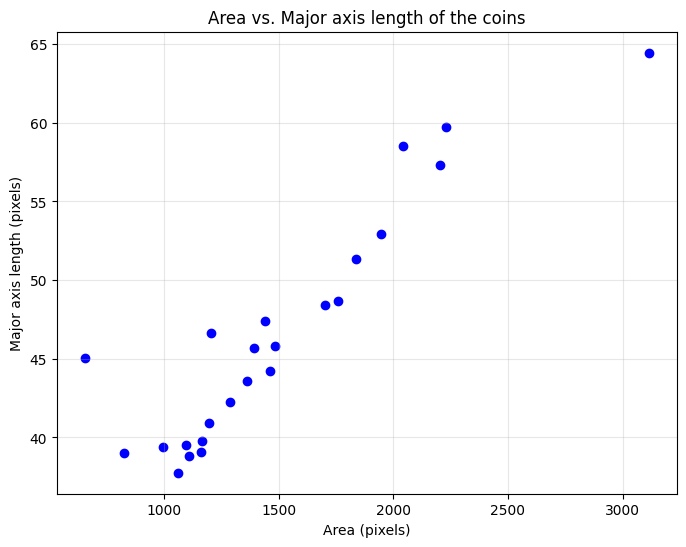

In [36]:
from skimage.measure import regionprops

props = regionprops(label_image)

area        = np.array([p.area for p in props])
major_axis  = np.array([p.axis_major_length for p in props])
orientation = np.degrees(np.array([p.orientation for p in props]))   # convert to degrees

print('\nAVERAGE area               = {:.2f} pixels'.format(area.mean()))
print('AVERAGE major axis length  = {:.2f} pixels'.format(major_axis.mean()))
print('AVERAGE orientation        = {:.2f} degrees'.format(orientation.mean()))

# Scatterplot of the area vs. major axis length
fig = plt.figure(figsize=(8, 6))
plt.scatter(area, major_axis, c='b')
plt.xlabel('Area (pixels)')
plt.ylabel('Major axis length (pixels)')
plt.title('Area vs. Major axis length of the coins')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

In [37]:
big_coins = [p for p in props if p.area > 1750]

print('There are {} coins with an area greater than 1750 pixels'.format(len(big_coins)))
print('Their labels are : {}'.format([p.label for p in big_coins]))
print('Their areas are  : {}'.format([int(p.area) for p in big_coins]))

n_big = int(np.sum(area > 1750))
print('\nUsing a boolean mask on the area array -> {} coins with area > 1750'.format(n_big))

There are 7 coins with an area greater than 1750 pixels
Their labels are : [1, 7, 13, 19, 20, 21, 22]
Their areas are  : [2231, 1836, 3114, 2042, 2204, 1947, 1759]

Using a boolean mask on the area array -> 7 coins with area > 1750


##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

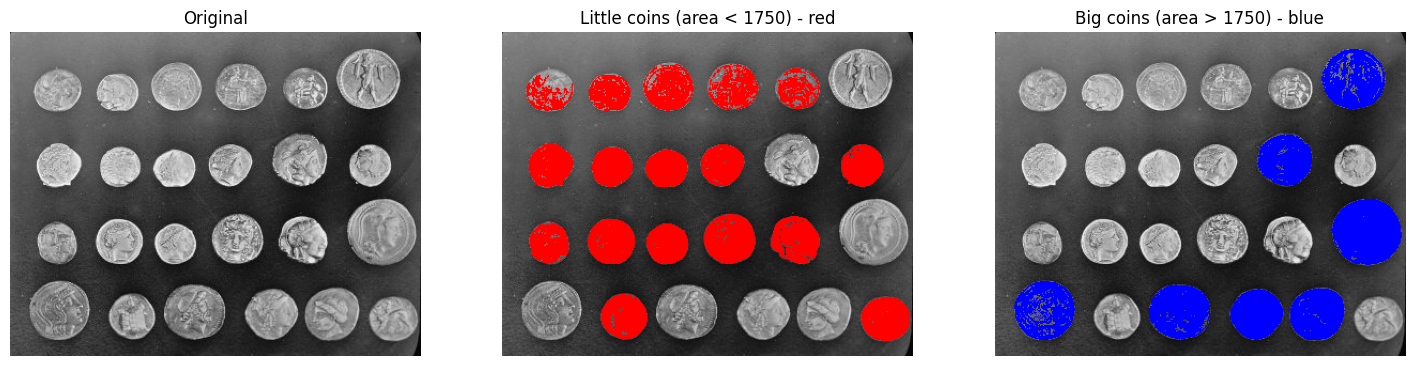

In [38]:
small_mask = np.zeros(I.shape, dtype=bool)
big_mask   = np.zeros(I.shape, dtype=bool)
for p in props:
    if p.area > 1750:
        big_mask[label_image == p.label] = True      # big coins
    else:
        small_mask[label_image == p.label] = True     # little coins

# RGB overlays on top of the grayscale image
base = np.dstack([I, I, I]).astype(float) / 255.0

img_small = base.copy(); img_small[small_mask] = [1, 0, 0]   # little coins in RED
img_big   = base.copy(); img_big[big_mask]     = [0, 0, 1]   # big coins in BLUE

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(I, cmap=plt.cm.gray); ax[0].set_title('Original');                       ax[0].axis('off')
ax[1].imshow(img_small);           ax[1].set_title('Little coins (area < 1750) - red'); ax[1].axis('off')
ax[2].imshow(img_big);             ax[2].set_title('Big coins (area > 1750) - blue');    ax[2].axis('off')
plt.show()

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

Main steps to segment an RGB image with an unsupervised clustering algorithm:
  1) Read the RGB image  ->  array of shape (rows, cols, 3).
  2) Reshape it to a feature matrix of shape (N_pixels, 3): every pixel is one observation and the 3 colour channels (R, G, B) are its features.
  3) (Optionally normalise the features or change the colour space)
  4) Choose an unsupervised clustering algorithm and fit it to the pixel features.
  5) Predict a cluster label for every pixel.
  6) Reshape the labels back to the image size and visualise the segmentation.

Here I use Gaussian Mixture Models (GMM) algorithm as it's different from K-means and compare

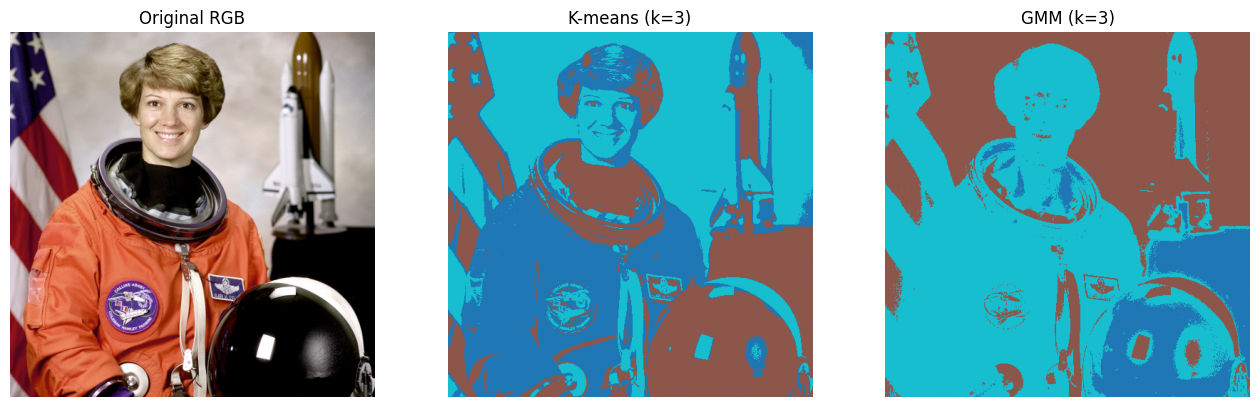

GMM with BIC model selection -> best number of clusters = 6


In [30]:
from sklearn import mixture

# 1) read an RGB image
IC = data.astronaut()

# 2) reshape to a (N_pixels, 3) feature matrix (float for the clustering models)
v_C = np.reshape(IC, (IC.shape[0]*IC.shape[1], IC.shape[2])).astype(float)

n_clus = 3

# 4-5) K-means
kmeans_rgb = KMeans(n_clusters=n_clus, random_state=0, n_init=10).fit(v_C)
seg_kmeans = kmeans_rgb.predict(v_C).reshape(IC.shape[0], IC.shape[1])

# 4-5) Gaussian Mixture Model (GMM)
gmm = mixture.GaussianMixture(n_components=n_clus, random_state=0).fit(v_C)
seg_gmm = gmm.predict(v_C).reshape(IC.shape[0], IC.shape[1])

# 6) visualise and compare
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(IC);                            ax[0].set_title('Original RGB');  ax[0].axis('off')
ax[1].imshow(seg_kmeans, cmap=plt.cm.tab10); ax[1].set_title('K-means (k=3)'); ax[1].axis('off')
ax[2].imshow(seg_gmm, cmap=plt.cm.tab10);    ax[2].set_title('GMM (k=3)');     ax[2].axis('off')
plt.show()

NMAX = 6
bic = []
for kG in np.arange(1, NMAX+1):
    g = mixture.GaussianMixture(n_components=kG, covariance_type='full', random_state=0).fit(v_C)
    bic.append(g.bic(v_C))
idx_winner = int(np.argmin(bic))
print('GMM with BIC model selection -> best number of clusters = {}'.format(idx_winner + 1))

- K-means assigns each pixel to the NEAREST centroid -> spherical clusters of similar size; it only needs the number of clusters k.
- GMM models each cluster as a Gaussian distribution with its own covariance, so it captures elliptical clusters of different size/orientation and gives soft (probabilistic) assignments. The number of components can be chosen objectively with the BIC criterion, as shown above.

## 10. Extract the main texture features of this image

In [31]:
import pandas as pd
from skimage.feature.texture import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

g = graycomatrix(I, [1], [0], levels=None, normed=True, symmetric=True)

contrast      = graycoprops(g, 'contrast')
dissimilarity = graycoprops(g, 'dissimilarity')
homogeneity   = graycoprops(g, 'homogeneity')
energy        = graycoprops(g, 'energy')
correlation   = graycoprops(g, 'correlation')

print('Main texture features of the coins image:')
print('  Contrast      = {:.4f}'.format(contrast[0, 0]))
print('  Dissimilarity = {:.4f}'.format(dissimilarity[0, 0]))
print('  Homogeneity   = {:.4f}'.format(homogeneity[0, 0]))
print('  Energy        = {:.4f}'.format(energy[0, 0]))
print('  Correlation   = {:.4f}'.format(correlation[0, 0]))
print('  Shannon entropy = {:.4f} bits/pixel'.format(shannon_entropy(I)))


Main texture features of the coins image:
  Contrast      = 351.8455
  Dissimilarity = 9.2926
  Homogeneity   = 0.2382
  Energy        = 0.0196
  Correlation   = 0.9372
  Shannon entropy = 7.5244 bits/pixel


## Personal discussion

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)

I feel I have gained a clear and well-structured understanding of how a digital image can be turned into useful, quantitative information. The course was organised in a very logical way, moving step by step from image pre-processing (reading images, histograms, intensity transforms, filtering and denoising), to image segmentation (thresholding, K-means, GMM and supervised methods), and finally to image classification and feature extraction (regional attributes, texture analysis with the GLCM, and Shannon's entropy). This progression made each new topic feel like a natural continuation of the previous one.

What I value the most is that the course combined theory and practice so well. For almost every concept there was an intuitive explanation, the mathematical formulation, and a hands-on Python example using skimage and scikit-learn.